In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from src.transcripts import (
    load_all_transcripts,
    filter_only_participants,
    concat_text_per_participant,
)
from src.features import simple_features

In [2]:
df = load_all_transcripts()
print("Wszystkich wierszy (wypowiedzi):", len(df))
print("Uczestników:", df["participant_id"].nunique())
df.head()

Wszystkich wierszy (wypowiedzi): 14835
Uczestników: 38


,speaker_id,slide_id,question_id,problem_id,text,participant_id,group
0,DR,NaN,NaN,NaN,Transkrypcja została włączona i ona sobie tut...,DR_IT_05,IT
1,DR,NaN,NaN,NaN,Tak mamy.,DR_IT_05,IT
2,DR,NaN,NaN,NaN,"I zrobimy może w ten sposób, że ja panią zap...",DR_IT_05,IT
3,DR,NaN,NaN,NaN,Około pani.,DR_IT_05,IT
4,DR,NaN,NaN,NaN,Wszystko jest w porządku.,DR_IT_05,IT


In [3]:
df.drop_duplicates("participant_id")["group"].value_counts()

group
SSH    18
DE     12
IT      8
Name: count, dtype: int64

In [4]:
df[df["participant_id"] == "MW_SSH_05"].head(10)

,speaker_id,slide_id,question_id,problem_id,text,participant_id,group
7176,MW,NaN,NaN,NaN,"Będziemy pracować taką metodą, która nazywa si...",MW_SSH_05,SSH
7177,MW_SSH_05,NaN,NaN,NaN,"To będzie dość proste, bo już jestem (anonimiz...",MW_SSH_05,SSH
7178,MW,NaN,NaN,NaN,"Tak, doświadczony użytkownik badań, bardzo doc...",MW_SSH_05,SSH
7179,MW_SSH_05,NaN,NaN,NaN,Nieraz.,MW_SSH_05,SSH
7180,MW,NaN,NaN,NaN,"Nieraz, czyli rozumiem, że dodawanie, odejmowa...",MW_SSH_05,SSH
7181,MW_SSH_05,NaN,NaN,NaN,"Do komentarzy muszę się zastanowić, bo nie jes...",MW_SSH_05,SSH
7182,MW,NaN,NaN,NaN,"To możemy sobie wejść teraz do tego folderu, k...",MW_SSH_05,SSH
7183,MW_SSH_05,NaN,NaN,NaN,A (ns - 00:02:21).,MW_SSH_05,SSH
7184,MW,NaN,NaN,NaN,Będziemy wiedzieć. Czyli prezentację można sob...,MW_SSH_05,SSH
7185,MW_SSH_05,NaN,NaN,NaN,"Nigdy nie używałem komentarzy, nie próbowałem ...",MW_SSH_05,SSH


In [5]:
print("Przed filtracją:", len(df))
df_part = filter_only_participants(df)
print("Po filtracji (tylko uczestnicy):", len(df_part))

Przed filtracją: 14835
Po filtracji (tylko uczestnicy): 11434


In [6]:
text_df = concat_text_per_participant(df_part)
print("Ramka per uczestnik:", text_df.shape)
text_df.head()

Ramka per uczestnik: (38, 3)


,participant_id,group,text
0,DR_IT_05,IT,", czyli wzięły nam zostanie z niego. Że jest z..."
1,DR_SSH_01,SSH,"Tak, jestem gotowa Czyli odpowiedzieć mam na p..."
2,DR_SSH_02,SSH,W porządku zatem można tam póki co czytam pier...
3,DR_SSH_03,SSH,W takim razie czytam prezentację. Tam zapewn...
4,DR_SSH_04,SSH,"Czyli będę musiał wysyłać wszystko, co robię ..."


In [7]:
# średnia długość wypowiedzi w znakach per grupa
text_df["text_len"] = text_df["text"].str.len()
text_df.groupby("group")["text_len"].agg(["mean", "min", "max"]).round(0)

,mean,min,max
group,,,
DE,24467.0,8937,46040
IT,38115.0,12053,89637
SSH,33791.0,18763,67506


Eksperci (DE) - krótsze wypowiedzi niż studenci.

In [8]:
feats = simple_features(text_df)
feats.head(10)

,n_words,ttr,avg_word_len,questions_per_1k,uncertainty_per_1k,ignorance_per_1k
participant_id,,,,,,
DR_IT_05,5394,0.281795,5.106971,10.938079,17.241379,3.151650
DR_SSH_01,2873,0.322659,5.351549,6.961364,15.315002,2.436478
DR_SSH_02,6406,0.243834,5.082111,4.527006,19.669060,3.434280
DR_SSH_03,4157,0.230936,5.324753,2.165023,24.777484,1.443349
DR_SSH_04,3388,0.270956,4.858619,10.035419,14.462810,6.788666
DR_SSH_06,5905,0.271804,4.940728,13.717189,16.088061,5.080440
DR_SSH_07,5053,0.205225,4.869187,7.124481,17.811201,10.093014
MK_IT_03,7458,0.192947,5.022526,6.972379,23.732904,4.022526
MK_IT_06,5156,0.220132,4.821373,5.818464,27.734678,4.460822


In [9]:
feats_with_group = feats.join(text_df.set_index("participant_id")["group"])
feats_with_group.groupby("group").mean().round(2)

,n_words,ttr,avg_word_len,questions_per_1k,uncertainty_per_1k,ignorance_per_1k
group,,,,,,
DE,3898.50,0.28,4.97,7.39,14.81,3.80
IT,6201.12,0.23,4.92,7.93,21.11,4.86
SSH,5488.78,0.23,4.94,8.51,21.29,5.33


In [10]:
from sklearn.preprocessing import StandardScaler

ids = feats.index.tolist()
X_scaled = StandardScaler().fit_transform(feats.values)

In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_scaled)

results = pd.DataFrame({
    "participant_id": ids,
    "cluster": clusters,
})
results = results.merge(text_df[["participant_id", "group"]], on="participant_id")

print("Wielkość klastrów:")
print(results["cluster"].value_counts().sort_index())

Wielkość klastrów:
cluster
0    16
1    13
2     9
Name: count, dtype: int64


In [12]:
pd.crosstab(results["cluster"], results["group"], margins=True, margins_name="Razem")

group,DE,IT,SSH,Razem
cluster,,,,
0,10,3,3,16
1,2,3,8,13
2,0,2,7,9
Razem,12,8,18,38


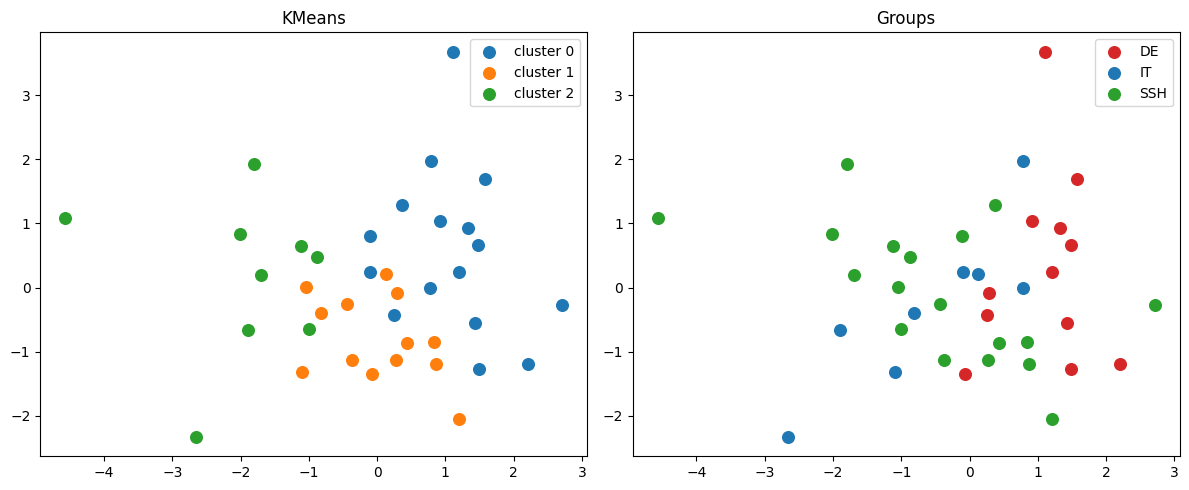

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for c in sorted(results["cluster"].unique()):
    mask = results["cluster"] == c
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], label=f"cluster {c}", s=70)
axes[0].set_title("KMeans")
axes[0].legend()

colors = {"DE": "tab:red", "IT": "tab:blue", "SSH": "tab:green"}
for g, col in colors.items():
    mask = results["group"] == g
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], label=g, s=70, c=col)
axes[1].set_title("Groups")
axes[1].legend()

plt.tight_layout()
plt.savefig("img/KMeans.png", dpi=110, bbox_inches="tight")
plt.show()